In [26]:
import pandas as pd
from sqlalchemy import create_engine

DB_NAME = "nba_data"
DB_USER = "postgres"
DB_PASSWORD = "password"
DB_HOST = "localhost"
DB_PORT = 5432

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)


In [40]:
#Load team_checkpoint_40 and identify numeric features

df40 = pd.read_sql("SELECT * FROM team_checkpoint_40;", engine)

id_like = {"season","game_id","team_id","opp_team_id","team_game_number"}
target = "made_playoffs"

num_cols = df40.select_dtypes(include="number").columns.tolist()
num_features = [c for c in num_cols if c not in id_like and c != target]

num_features

['is_home',
 'is_win',
 'point_diff',
 'fgm',
 'fga',
 'fg_pct',
 'fg3m',
 'fg3a',
 'fg3_pct',
 'ftm',
 'fta',
 'ft_pct',
 'oreb',
 'dreb',
 'reb',
 'ast',
 'stl',
 'blk',
 'turnovers',
 'pf',
 'pts',
 'plus_minus',
 'win_pct_l5',
 'win_pct_l10',
 'avg_point_diff_l10',
 'avg_pts_l10',
 'avg_tov_l10',
 'avg_reb_l10',
 'avg_ast_l10',
 'win_pct_s2d',
 'avg_point_diff_s2d']

In [28]:
#Full features audit table (missingness, summary stats, flags)
audit = pd.DataFrame({
    "dtype": df40[num_features].dtypes.astype(str),
    "missing_pct": (df40[num_features].isna().mean() * 100).round(2),
    "n_unique": df40[num_features].nunique(dropna=True),
    "mean": df40[num_features].mean(numeric_only=True),
    "std": df40[num_features].std(numeric_only=True),
    "min": df40[num_features].min(numeric_only=True),
    "p01": df40[num_features].quantile(0.01),
    "median": df40[num_features].median(numeric_only=True),
    "p99": df40[num_features].quantile(0.99),
    "max": df40[num_features].max(numeric_only=True),
}).sort_values(["missing_pct","n_unique"], ascending=[False, True])

# simple flags
audit["is_constant"] = audit["n_unique"] <= 1
audit["has_extreme_outliers"] = (audit["max"] > audit["p99"] * 3) & (audit["p99"] != 0)

audit

,dtype,missing_pct,n_unique,mean,std,min,p01,median,p99,max,is_constant,has_extreme_outliers
is_home,int64,0.0,2,0.493333,0.501630,0.000000,0.000000,0.000000,1.000000,1.000000,False,False
is_win,int64,0.0,2,0.513333,0.501497,0.000000,0.000000,1.000000,1.000000,1.000000,False,False
win_pct_l5,float64,0.0,6,0.502667,0.256708,0.000000,0.000000,0.600000,1.000000,1.000000,False,False
win_pct_l10,float64,0.0,9,0.502667,0.189647,0.100000,0.100000,0.500000,0.900000,0.900000,False,False
blk,int64,0.0,12,4.860000,2.410909,0.000000,1.000000,4.500000,10.000000,11.000000,False,False
oreb,int64,0.0,16,10.000000,3.557769,3.000000,4.000000,10.000000,18.000000,18.000000,False,False
stl,int64,0.0,16,7.453333,3.086204,1.000000,1.490000,7.000000,14.510000,17.000000,False,False
turnovers,int64,0.0,18,12.660000,3.581890,5.000000,5.490000,12.000000,21.000000,23.000000,False,False
fg3m,int64,0.0,19,12.866667,3.848937,4.000000,5.000000,13.000000,21.510000,22.000000,False,False
pf,int64,0.0,23,19.220000,4.178677,7.000000,8.980000,19.000000,28.510000,31.000000,False,False


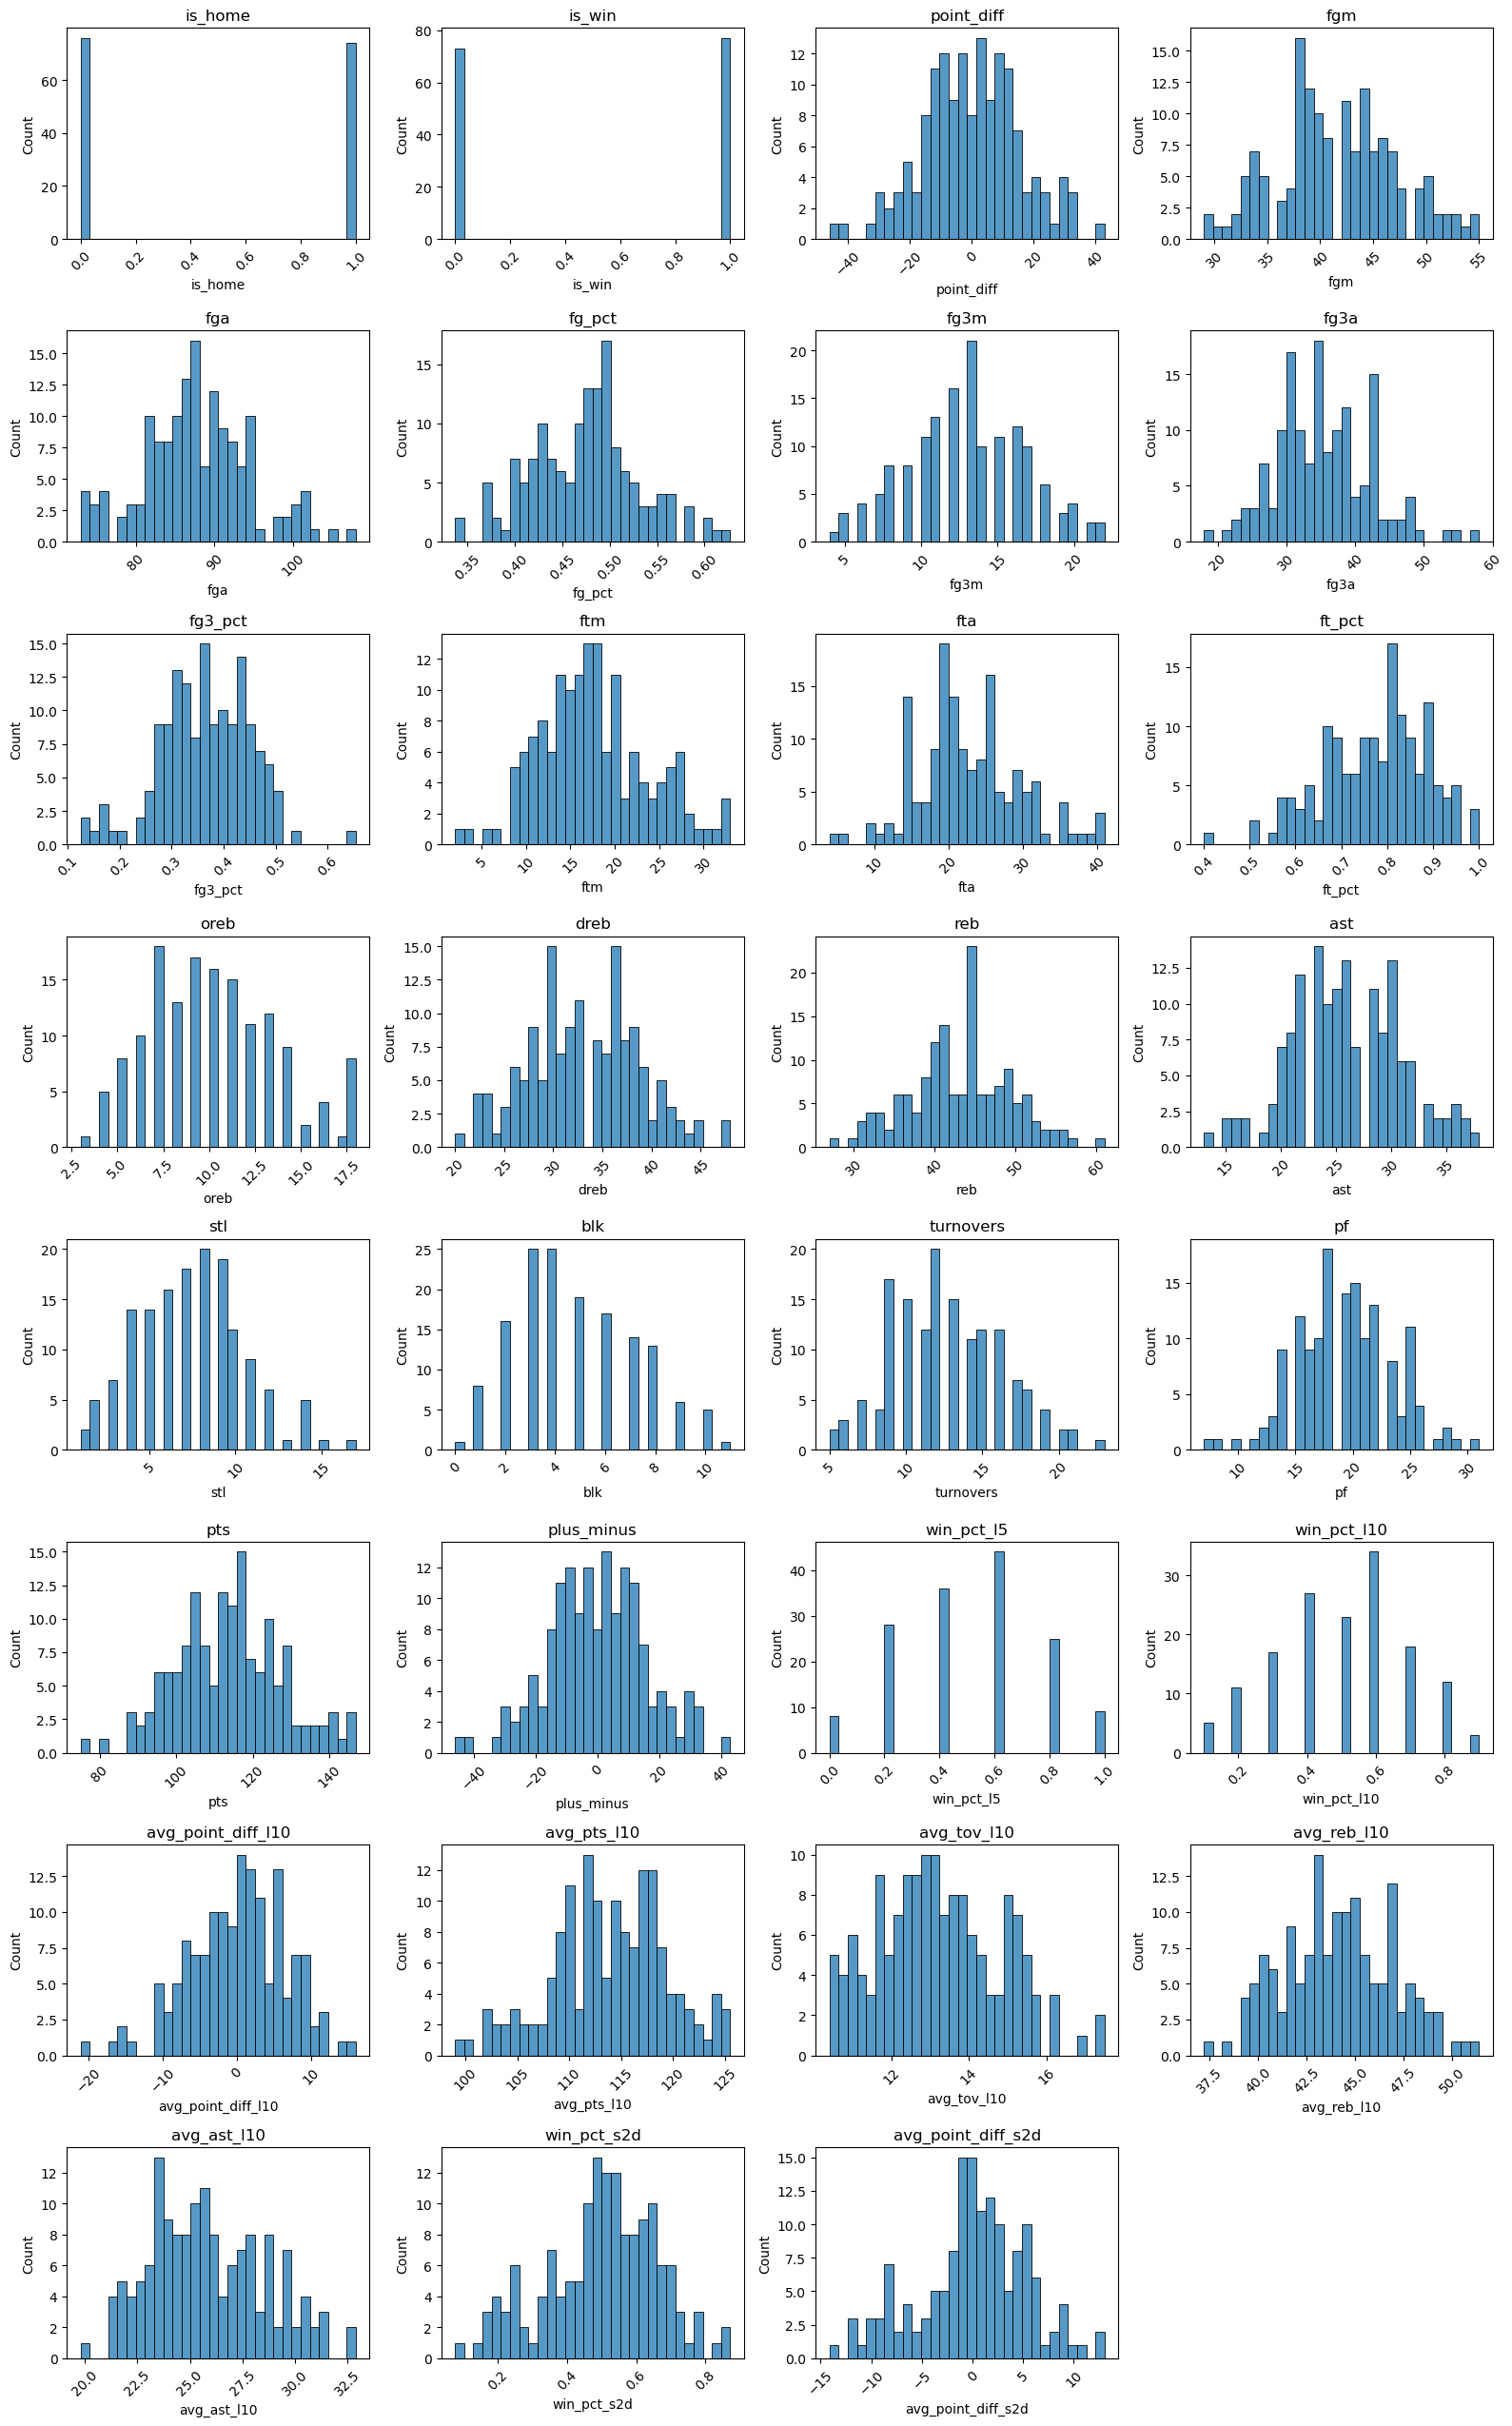

In [29]:
#Histogram view of all features distribution scan
import math

cols_per_row = 4
rows = math.ceil(len(num_features) / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 3.2*rows))
axes = axes.flatten()

for i, c in enumerate(num_features):
    sns.histplot(df40[c], ax=axes[i], bins=30)
    axes[i].set_title(c)
    axes[i].tick_params(axis='x', labelrotation=45)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

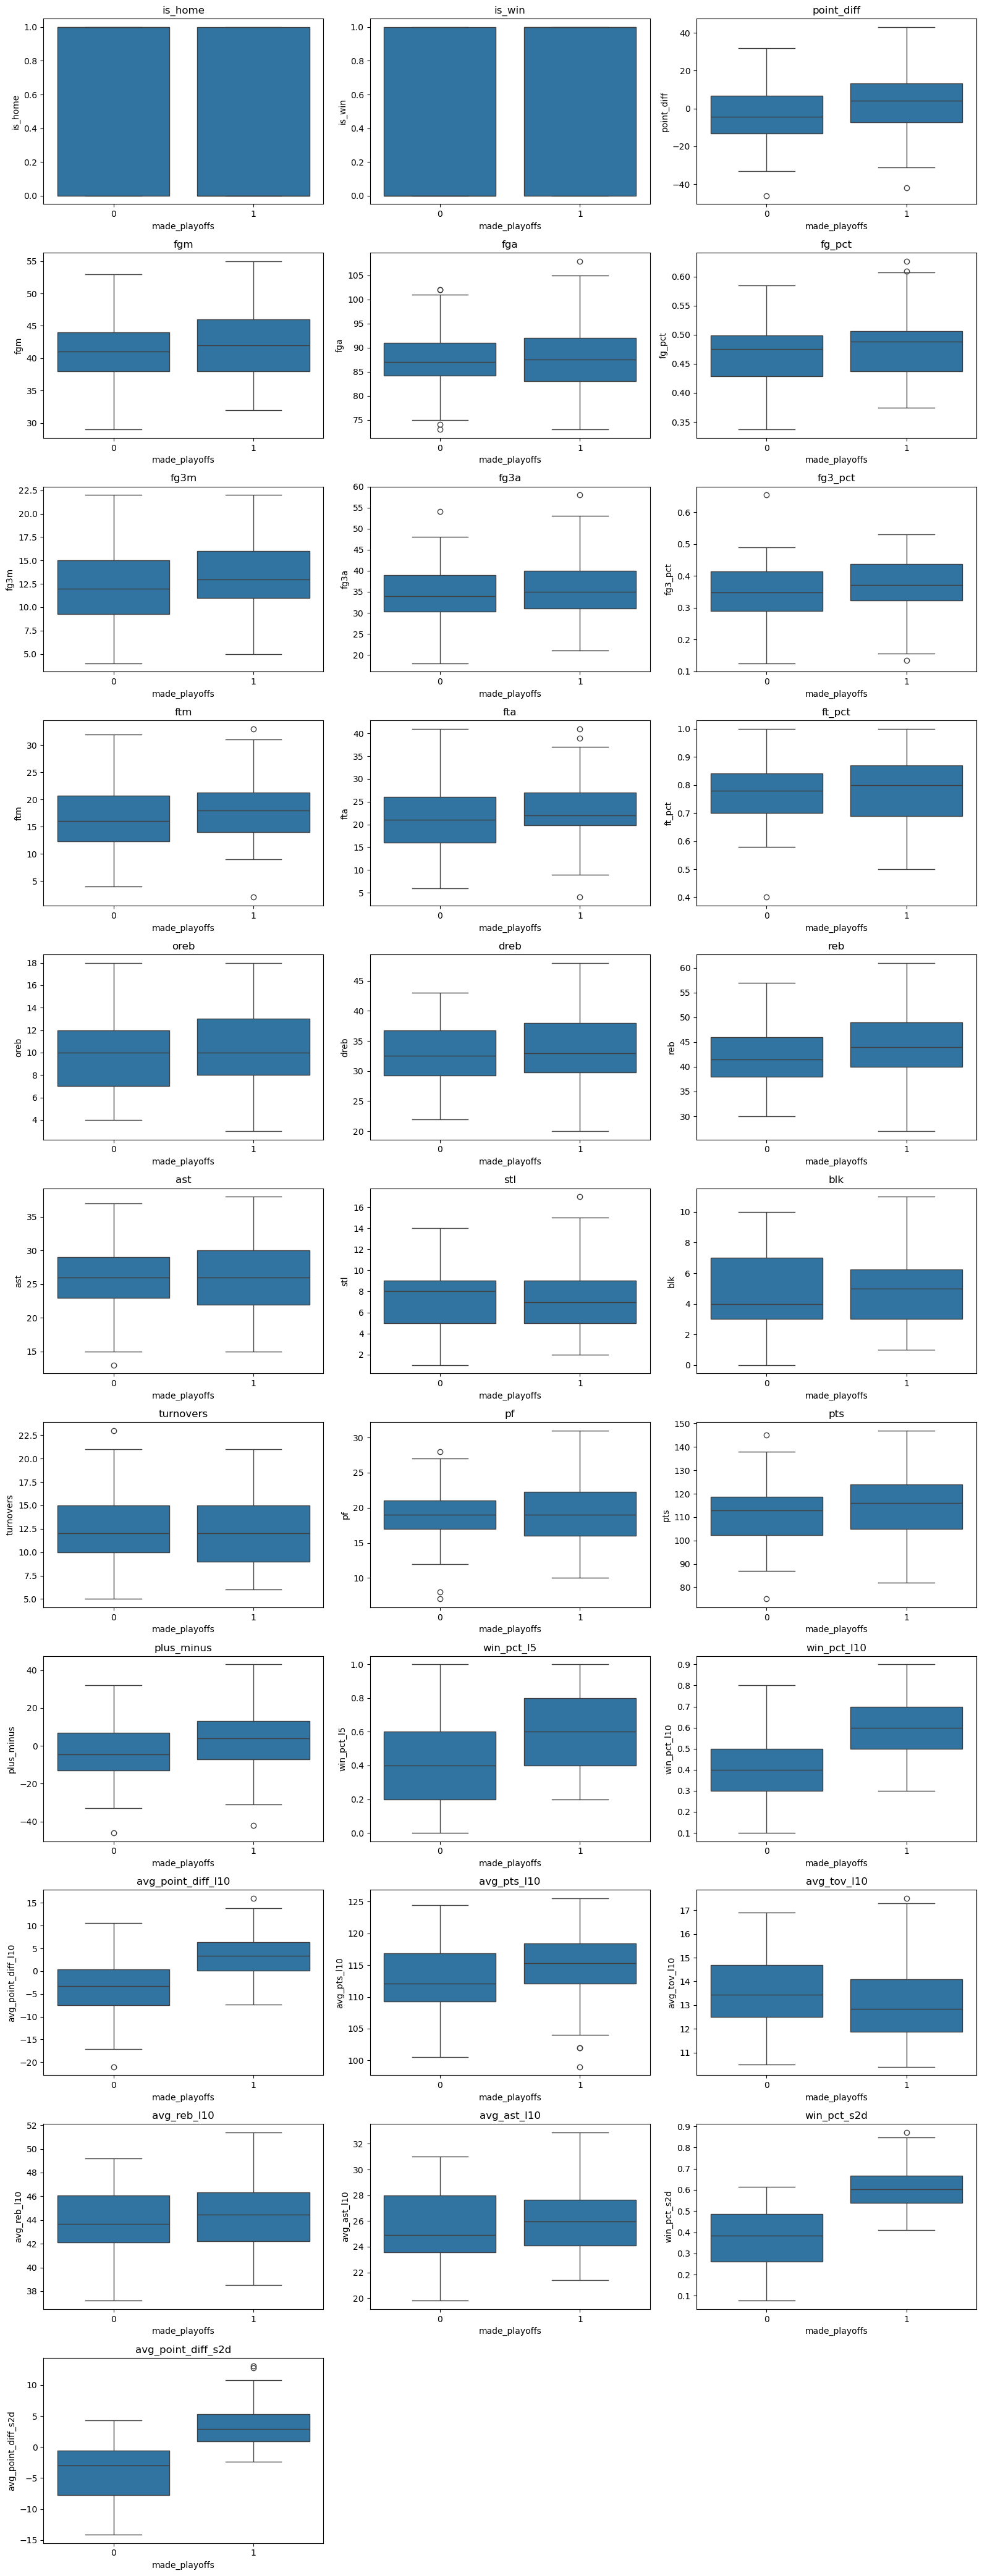

In [30]:
#Signal check for every feature vs. target
cols_per_row = 3
rows = math.ceil(len(num_features) / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 3.8*rows))
axes = axes.flatten()

for i, c in enumerate(num_features):
    sns.boxplot(data=df40, x=target, y=c, ax=axes[i])
    axes[i].set_title(c)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [42]:
#Rank features by playoff v. non-playoff delta
rank = []
for c in num_features:
    g1 = df40.loc[df40[target]==1, c].dropna()
    g0 = df40.loc[df40[target]==0, c].dropna()
    if len(g1) < 5 or len(g0) < 5:
        continue
    # simple standardized difference (Cohen's d-ish)
    d = (g1.mean() - g0.mean()) / (df40[c].std() if df40[c].std() else 1.0)
    rank.append((c, abs(d), d, g1.mean(), g0.mean()))

rank_df = pd.DataFrame(rank, columns=["feature","abs_std_diff","std_diff_signed","mean_playoff","mean_nonplayoff"])
rank_df.sort_values("abs_std_diff", ascending=False).head(15)


,feature,abs_std_diff,std_diff_signed,mean_playoff,mean_nonplayoff
29,win_pct_s2d,1.431639,1.431639,0.604167,0.380220
30,avg_point_diff_s2d,1.366159,1.366159,3.384615,-3.863370
24,avg_point_diff_l10,1.107244,1.107244,3.415000,-3.760000
23,win_pct_l10,1.099787,1.099787,0.600000,0.391429
22,win_pct_l5,0.854223,0.854223,0.605000,0.385714
1,is_win,0.583966,0.583966,0.650000,0.357143
21,plus_minus,0.518528,0.518528,3.737500,-4.414286
2,point_diff,0.518528,0.518528,3.737500,-4.414286
25,avg_pts_l10,0.465490,0.465490,115.091250,112.515714
26,avg_tov_l10,0.300660,-0.300660,13.023750,13.492857


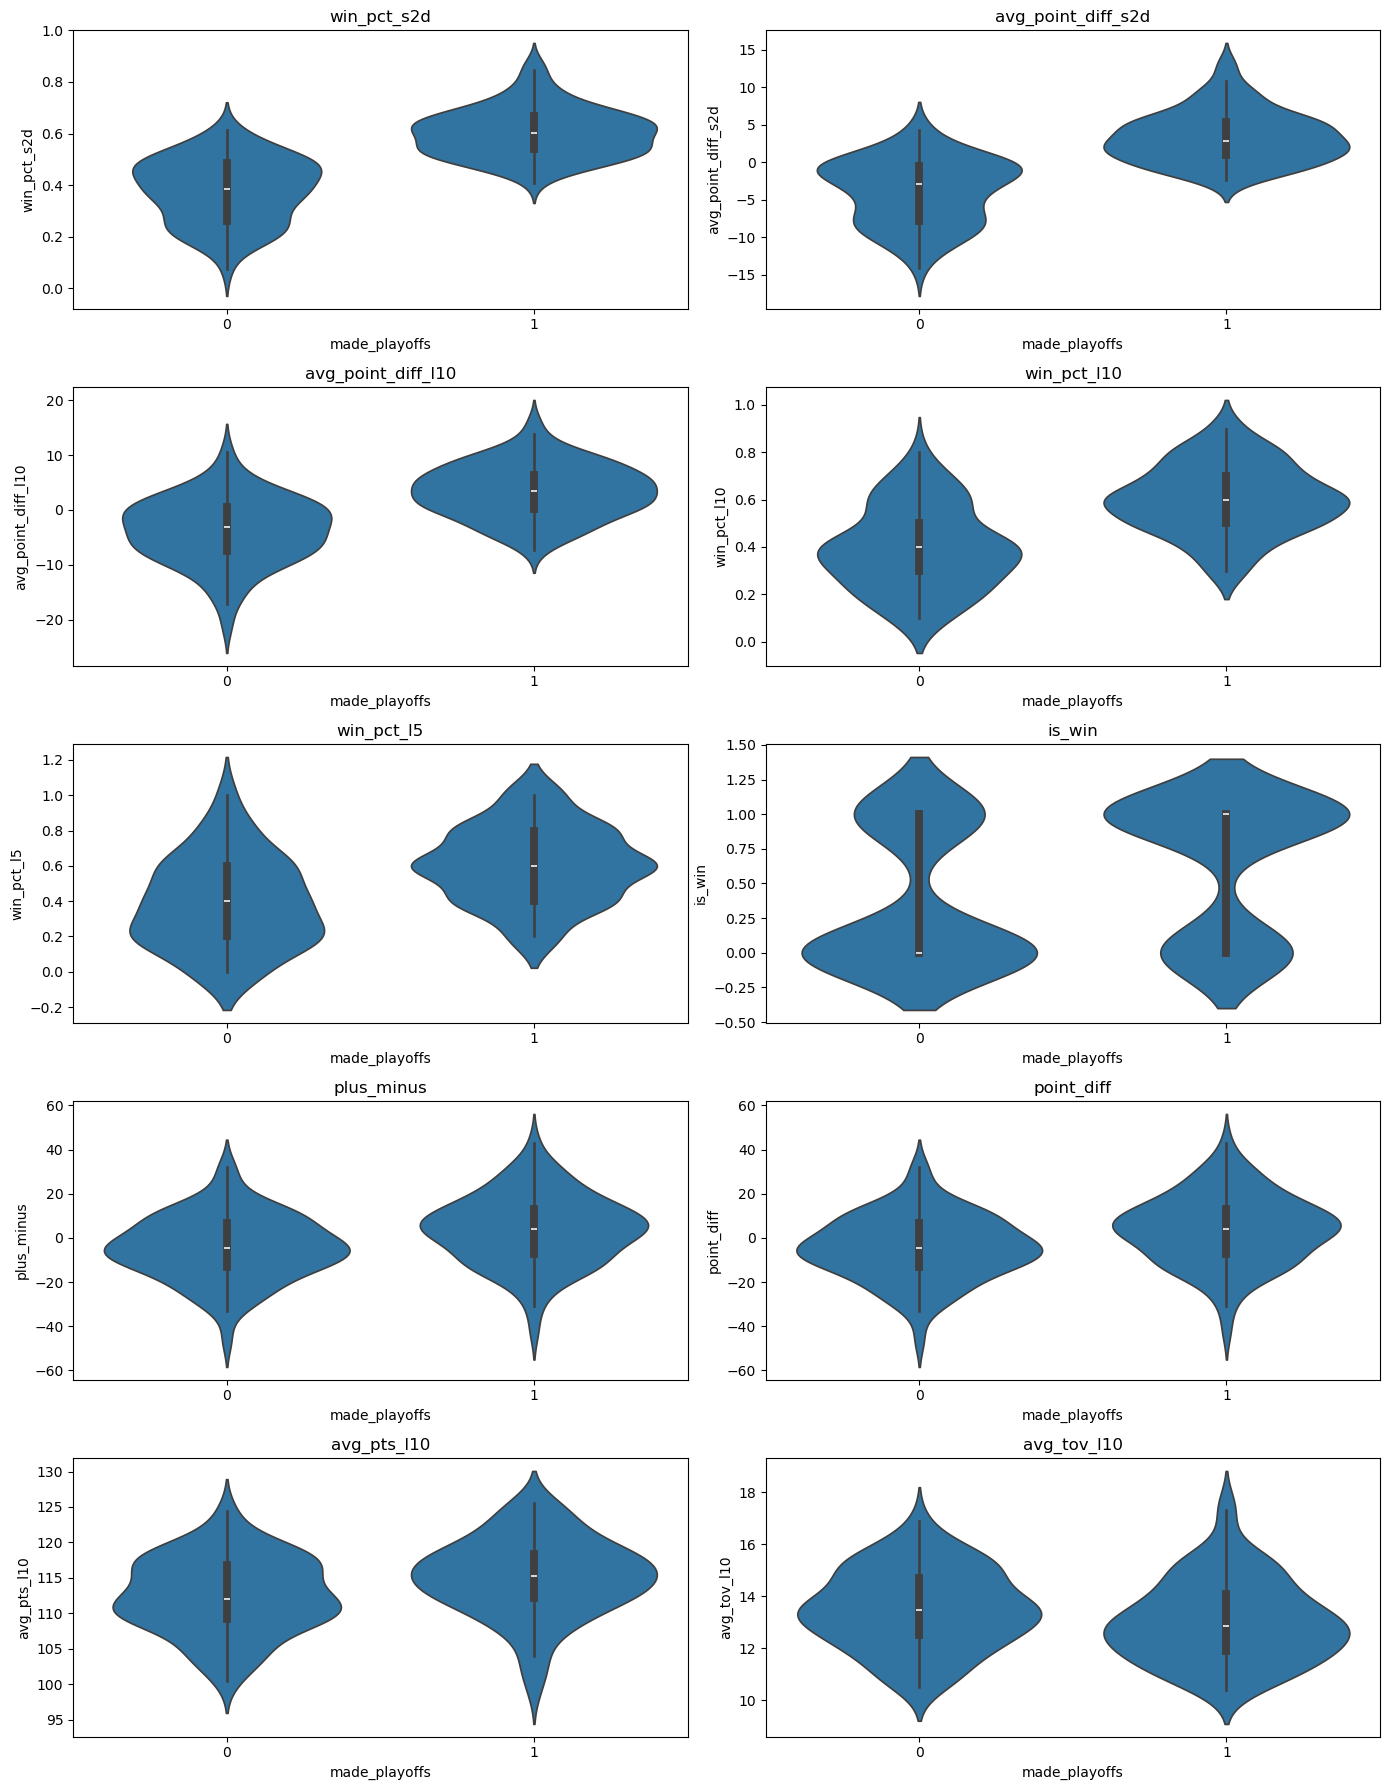

In [44]:
#Plot the top 10
top_feats = rank_df.sort_values("abs_std_diff", ascending=False)["feature"].head(10).tolist()

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
for i, c in enumerate(top_feats):
    sns.violinplot(data=df40, x=target, y=c, ax=axes[i])
    axes[i].set_title(c)
plt.tight_layout()
plt.show()
